In [5]:
import pandas as pd
import os
import glob

# Tìm tất cả các file products.csv trong thư mục data và các thư mục con
file_paths = glob.glob('data/*/products.csv')
df_list = []

for file in file_paths:
    temp_df = pd.read_csv(file)
    # Trích xuất ngày từ tên thư mục (ví dụ: data/03-25-2026/products.csv)
    date_str = file.split(os.sep)[-2] 
    temp_df['ngay_thu_thap'] = pd.to_datetime(date_str, format='%m-%d-%Y')
    df_list.append(temp_df)

# Gộp tất cả lại
df_master = pd.concat(df_list, ignore_index=True)
# Sắp xếp theo ID sản phẩm và Ngày thu thập
df_master = df_master.sort_values(by=['id', 'ngay_thu_thap'])

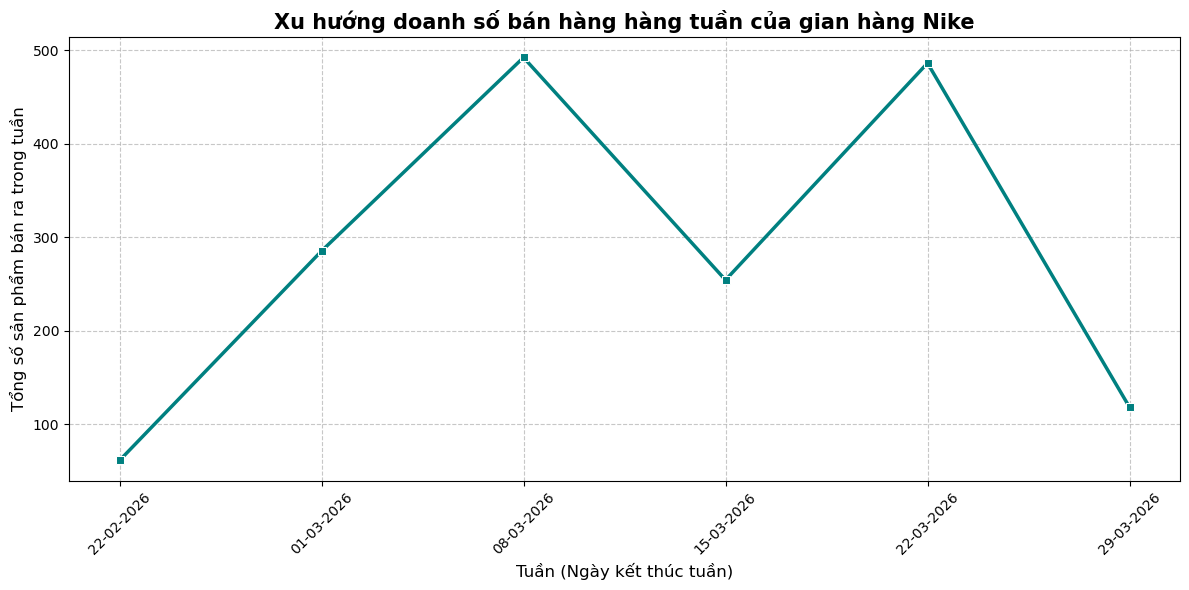

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# (Giả định cột ngay_thu_thap đã được chuyển sang định dạng datetime ở bước trước)
# Nếu chưa, chạy dòng này: df_master['ngay_thu_thap'] = pd.to_datetime(df_master['ngay_thu_thap'])

# 1. Tính số lượng bán mới mỗi ngày cho từng sản phẩm (Giữ nguyên logic cũ)
df_master['ban_trong_ngay'] = df_master.groupby('id')['so_luong_da_ban'].diff().fillna(0)
df_master.loc[df_master['ban_trong_ngay'] < 0, 'ban_trong_ngay'] = 0

# 2. Tổng hợp doanh số toàn gian hàng theo TUẦN
# Sử dụng resample('W', on='...') để gom nhóm dữ liệu theo từng tuần (mặc định chốt vào Chủ Nhật)
weekly_sales = df_master.resample('W', on='ngay_thu_thap')['ban_trong_ngay'].sum().reset_index()

# 3. Vẽ biểu đồ đường
plt.figure(figsize=(12, 6))
# Đổi marker thành 's' (square) và đổi màu để phân biệt với biểu đồ theo ngày
sns.lineplot(data=weekly_sales, x='ngay_thu_thap', y='ban_trong_ngay', marker='s', color='teal', linewidth=2.5)

plt.title('Xu hướng doanh số bán hàng hàng tuần của gian hàng Nike', fontsize=15, fontweight='bold')
plt.xlabel('Tuần (Ngày kết thúc tuần)', fontsize=12)
plt.ylabel('Tổng số sản phẩm bán ra trong tuần', fontsize=12)

# Định dạng lại trục X để hiển thị ngày/tháng rõ ràng hơn
plt.xticks(weekly_sales['ngay_thu_thap'], weekly_sales['ngay_thu_thap'].dt.strftime('%d-%m-%Y'), rotation=45)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

💰 TỔNG DOANH THU ƯỚC TÍNH TOÀN KỲ: 3,145,326,000 VNĐ


C:\Users\thanh\AppData\Local\Temp\ipykernel_16540\2512882564.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticks_labels, rotation=45)


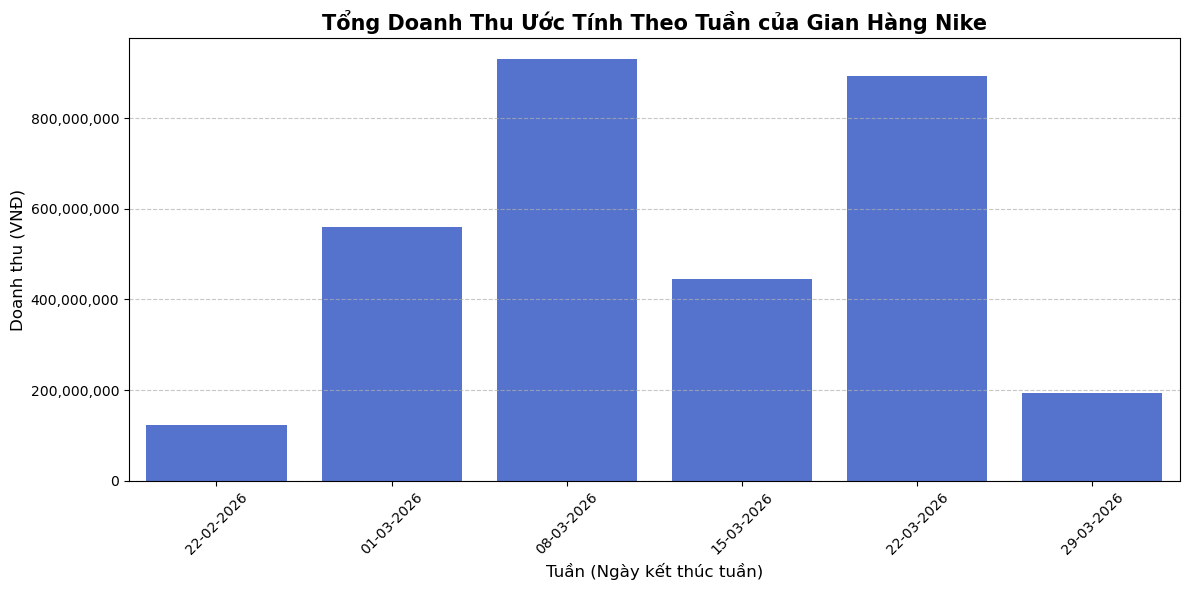

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. TÍNH DOANH THU TỪNG NGÀY CHO MỖI SẢN PHẨM
# Nhân số lượng bán mới của ngày hôm đó với giá bán của chính ngày hôm đó
df_master['doanh_thu_ngay'] = df_master['ban_trong_ngay'] * df_master['gia_ban']

# Tính TỔNG DOANH THU XUYÊN SUỐT TOÀN BỘ CHUỖI THỜI GIAN
tong_doanh_thu = df_master['doanh_thu_ngay'].sum()
print(f"💰 TỔNG DOANH THU ƯỚC TÍNH TOÀN KỲ: {tong_doanh_thu:,.0f} VNĐ")

# 2. TỔNG HỢP DOANH THU THEO TUẦN ĐỂ VẼ BIỂU ĐỒ
weekly_revenue = df_master.resample('W', on='ngay_thu_thap')['doanh_thu_ngay'].sum().reset_index()

# 3. TRỰC QUAN HÓA DOANH THU THEO TUẦN BẰNG BAR CHART (BIỂU ĐỒ CỘT)
plt.figure(figsize=(12, 6))
# Dùng Barplot thể hiện doanh thu thường mang lại cảm giác trực quan hơn Lineplot
ax = sns.barplot(data=weekly_revenue, x='ngay_thu_thap', y='doanh_thu_ngay', color='royalblue')

plt.title('Tổng Doanh Thu Ước Tính Theo Tuần của Gian Hàng Nike', fontsize=15, fontweight='bold')
plt.xlabel('Tuần (Ngày kết thúc tuần)', fontsize=12)
plt.ylabel('Doanh thu (VNĐ)', fontsize=12)

# Định dạng trục X hiển thị ngày tháng
xticks_labels = weekly_revenue['ngay_thu_thap'].dt.strftime('%d-%m-%Y')
ax.set_xticklabels(xticks_labels, rotation=45)

# Tắt định dạng 1e9, 1e10 của matplotlib trên trục Y để số tiền hiển thị đầy đủ
plt.ticklabel_format(style='plain', axis='y')
# Định dạng lại nhãn trục Y có dấu phẩy ngăn cách hàng nghìn cho dễ đọc
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()